In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/train_features.csv")

df.shape, df.head()

((149391, 36),
    SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines   age  \
 0                 1                              0.766127  45.0   
 1                 0                              0.957151  40.0   
 2                 0                              0.658180  38.0   
 3                 0                              0.233810  30.0   
 4                 0                              0.907239  49.0   
 
    NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
 0                                   2.0   0.802982         9120.0   
 1                                   0.0   0.121876         2600.0   
 2                                   1.0   0.085113         3042.0   
 3                                   0.0   0.036050         3300.0   
 4                                   1.0   0.024926        63588.0   
 
    NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
 0                               13                      0.0   
 1                       

In [10]:
target = "SeriousDlqin2yrs"

X = df.drop(columns=[target])
y = df[target]

print(X.shape)
print(y.value_counts(normalize=True))

(149391, 35)
SeriousDlqin2yrs
0    0.933001
1    0.066999
Name: proportion, dtype: float64


## 特征选择说明

当前使用了全部 35 列，其中原始偏态字段（`MonthlyIncome`、`DebtRatio`、`RevolvingUtilizationOfUnsecuredLines`）与其对应的 `_log` 版本高度共线。  
逻辑回归的 L2 正则化可以一定程度缓解多重共线性，但为了系数更可解释，建议在最终版本中二选一。  
本 notebook 暂时保留全部特征以观察基线效果，后续可根据系数图进行裁剪。

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_valid.shape)

(119512, 35) (29879, 35)


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


## 交叉验证基线 & 超参数调优

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 交叉验证基线（C=1.0）
cv_res = cross_validate(
    logistic_model, X_train, y_train, cv=cv,
    scoring=['roc_auc', 'average_precision', 'recall', 'f1'],
    n_jobs=-1
)

print('=== 5-Fold CV 基线（C=1.0, balanced）===')
for m in ['roc_auc', 'average_precision', 'recall', 'f1']:
    vals = cv_res[f'test_{m}']
    print(f'  {m:22s}: {vals.mean():.4f} ± {vals.std():.4f}')

=== 5-Fold CV 基线（C=1.0, balanced）===
  roc_auc               : 0.8599 ± 0.0015
  average_precision     : 0.3775 ± 0.0074
  recall                : 0.7656 ± 0.0053
  f1                    : 0.3323 ± 0.0019


In [14]:
# 超参数调优：搜索最优 C 和 penalty
param_grid = [
    {'model__penalty': ['l2'], 'model__C': [0.01, 0.1, 1.0, 10.0],
     'model__solver': ['lbfgs']},
    {'model__penalty': ['l1'], 'model__C': [0.01, 0.1, 1.0, 10.0],
     'model__solver': ['liblinear']},
]

gs = GridSearchCV(
    logistic_model, param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=0, refit=True
)
gs.fit(X_train, y_train)

print(f'最优参数: {gs.best_params_}')
print(f'最优 CV ROC-AUC: {gs.best_score_:.4f}')

# 展示调优结果
cv_df = pd.DataFrame(gs.cv_results_)[
    ['param_model__C', 'param_model__penalty', 'mean_test_score', 'std_test_score']
].rename(columns={
    'param_model__C': 'C',
    'param_model__penalty': 'penalty',
    'mean_test_score': 'mean_AUC',
    'std_test_score': 'std_AUC'
}).sort_values('mean_AUC', ascending=False).reset_index(drop=True)

print()
print(cv_df.round(4))

# 使用最优模型
best_model = gs.best_estimator_

最优参数: {'model__C': 0.01, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
最优 CV ROC-AUC: 0.8600

       C penalty  mean_AUC  std_AUC
0   0.01      l2    0.8600   0.0015
1   0.01      l1    0.8600   0.0014
2   0.10      l1    0.8600   0.0015
3   0.10      l2    0.8600   0.0015
4  10.00      l2    0.8599   0.0015
5   1.00      l1    0.8599   0.0015
6   1.00      l2    0.8599   0.0015
7  10.00      l1    0.8599   0.0015


In [15]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_pred = logistic_model.predict(X_valid)
y_proba = logistic_model.predict_proba(X_valid)[:, 1]

auc = roc_auc_score(y_valid, y_proba)

print("ROC-AUC:", auc)
print(classification_report(y_valid, y_pred))
print(confusion_matrix(y_valid, y_pred))

ROC-AUC: 0.8596730689764374
              precision    recall  f1-score   support

           0       0.98      0.79      0.88     27877
           1       0.21      0.78      0.33      2002

    accuracy                           0.79     29879
   macro avg       0.60      0.79      0.60     29879
weighted avg       0.93      0.79      0.84     29879

[[22076  5801]
 [  439  1563]]


## 完整指标评估（最优模型）

=== 最优模型验证集评估 ===
ROC-AUC : 0.8597
PR-AUC  : 0.3824
Gini    : 0.7193

              precision    recall  f1-score   support

       正常(0)       0.98      0.79      0.88     27877
       违约(1)       0.21      0.78      0.33      2002

    accuracy                           0.79     29879
   macro avg       0.60      0.79      0.60     29879
weighted avg       0.93      0.79      0.84     29879



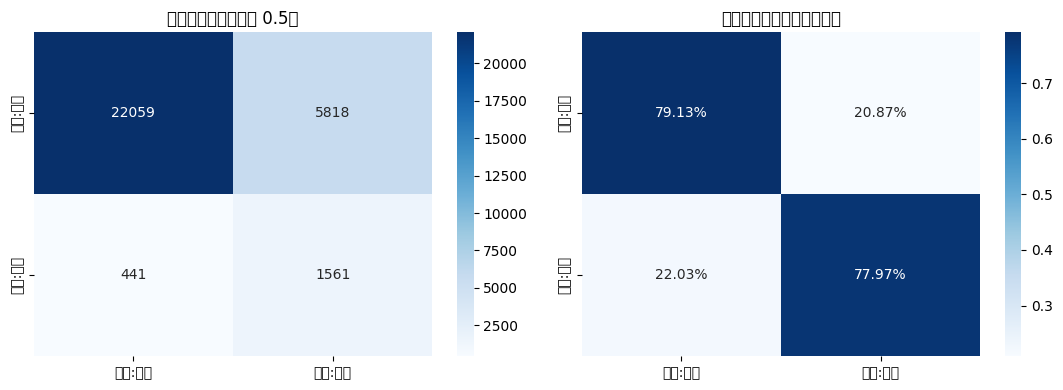

In [16]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import seaborn as sns

y_proba_best = best_model.predict_proba(X_valid)[:, 1]
y_pred_best  = best_model.predict(X_valid)

roc_auc = roc_auc_score(y_valid, y_proba_best)
pr_auc  = average_precision_score(y_valid, y_proba_best)
gini    = 2 * roc_auc - 1

print('=== 最优模型验证集评估 ===')
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')
print(f'Gini    : {gini:.4f}')
print()
print(classification_report(y_valid, y_pred_best, target_names=['正常(0)', '违约(1)']))

# 混淆矩阵热力图
cm = confusion_matrix(y_valid, y_pred_best)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['预测:正常', '预测:违约'],
            yticklabels=['实际:正常', '实际:违约'])
axes[0].set_title('混淆矩阵（默认阈值 0.5）')

# 归一化混淆矩阵（按实际类别归一化）
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['预测:正常', '预测:违约'],
            yticklabels=['实际:正常', '实际:违约'])
axes[1].set_title('混淆矩阵（归一化，按行）')
plt.tight_layout()
plt.show()

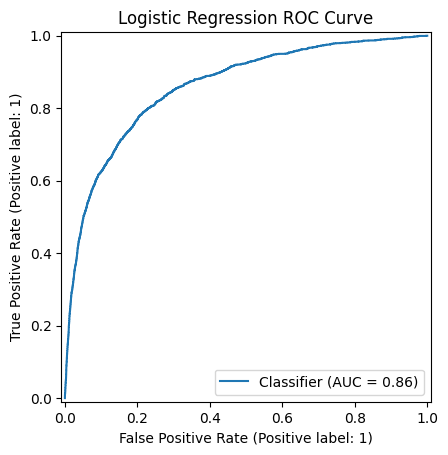

In [17]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

RocCurveDisplay.from_predictions(y_valid, y_proba)
plt.title("Logistic Regression ROC Curve")
plt.show()

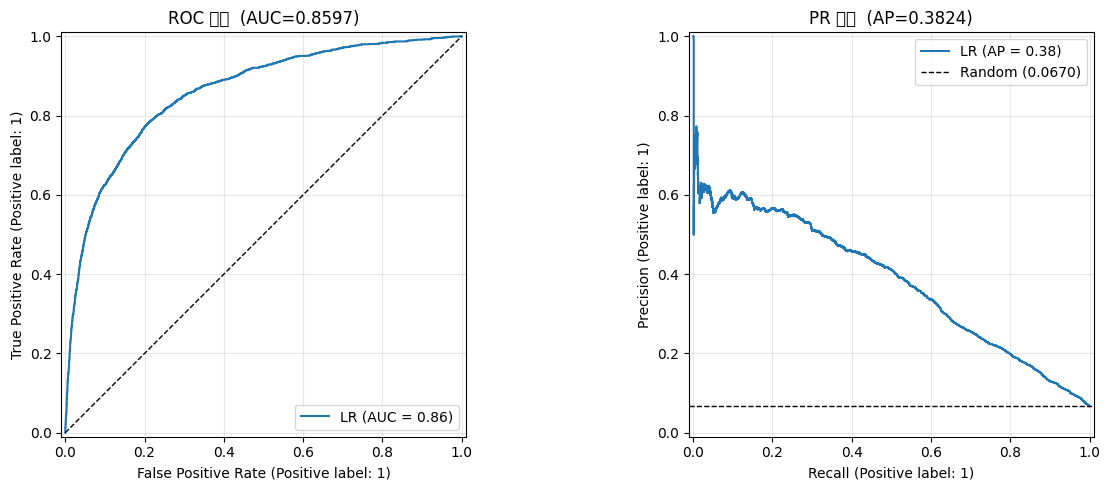

In [18]:
# PR 曲线
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(y_valid, y_proba_best, ax=axes[0], name='LR')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_title(f'ROC 曲线  (AUC={roc_auc:.4f})')
axes[0].grid(alpha=0.3)

PrecisionRecallDisplay.from_predictions(y_valid, y_proba_best, ax=axes[1], name='LR')
baseline = y_valid.mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Random ({baseline:.4f})')
axes[1].set_title(f'PR 曲线  (AP={pr_auc:.4f})')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## KS 统计量

KS（Kolmogorov-Smirnov）是信用评分的标准评估指标，衡量模型将好坏客户最大程度分开的能力。  
经验参考：KS < 0.2 差 | 0.2–0.4 一般 | 0.4–0.6 良好 | > 0.6 优秀

In [19]:
fpr_arr, tpr_arr, thresh_arr = roc_curve(y_valid, y_proba_best)
ks_arr    = tpr_arr - fpr_arr
ks_stat   = ks_arr.max()
ks_thresh = thresh_arr[np.argmax(ks_arr)]

print(f'KS 统计量 : {ks_stat:.4f}')
print(f'对应阈值  : {ks_thresh:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(thresh_arr, tpr_arr, label='TPR（召回率）', color='steelblue')
plt.plot(thresh_arr, fpr_arr, label='FPR（误报率）', color='tomato')
plt.plot(thresh_arr, ks_arr,  label=f'KS = TPR−FPR  (max={ks_stat:.4f})', color='green')
plt.axvline(ks_thresh, color='black', linestyle='--', alpha=0.6,
            label=f'KS 最优阈值={ks_thresh:.4f}')
plt.xlabel('阈值')
plt.title('KS 曲线')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'roc_curve' is not defined

## 决策阈值优化

默认阈值 0.5 不适合 93:7 的不平衡数据，扫描阈值找最优 F1 及业务约束（Recall ≥ 0.7）下的最优阈值。

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds  = np.arange(0.05, 0.95, 0.01)
f1_list, rec_list, prec_list = [], [], []

for t in thresholds:
    yt = (y_proba_best >= t).astype(int)
    f1_list.append(f1_score(y_valid, yt, zero_division=0))
    rec_list.append(recall_score(y_valid, yt, zero_division=0))
    prec_list.append(precision_score(y_valid, yt, zero_division=0))

f1_arr, rec_arr, prec_arr = map(np.array, [f1_list, rec_list, prec_list])

# 最优 F1
best_f1_idx    = np.argmax(f1_arr)
best_f1_thresh = thresholds[best_f1_idx]

# Recall ≥ 0.7 下精准率最高
valid_mask = rec_arr >= 0.7
if valid_mask.any():
    best_r70_idx    = np.where(valid_mask)[0][np.argmax(prec_arr[valid_mask])]
    best_r70_thresh = thresholds[best_r70_idx]
else:
    best_r70_thresh = None

print(f'最优 F1 阈值: {best_f1_thresh:.2f}  '
      f'F1={f1_arr[best_f1_idx]:.4f}  '
      f'Recall={rec_arr[best_f1_idx]:.4f}  '
      f'Precision={prec_arr[best_f1_idx]:.4f}')

if best_r70_thresh:
    i = best_r70_idx
    print(f'Recall≥0.7 最高精准率阈值: {best_r70_thresh:.2f}  '
          f'F1={f1_arr[i]:.4f}  Recall={rec_arr[i]:.4f}  Precision={prec_arr[i]:.4f}')

plt.figure(figsize=(10, 4))
plt.plot(thresholds, f1_arr,   label='F1',        color='steelblue')
plt.plot(thresholds, rec_arr,  label='Recall',     color='tomato')
plt.plot(thresholds, prec_arr, label='Precision',  color='green')
plt.axvline(best_f1_thresh, color='steelblue', linestyle='--', alpha=0.8,
            label=f'最优F1={best_f1_thresh:.2f}')
if best_r70_thresh:
    plt.axvline(best_r70_thresh, color='green', linestyle=':', alpha=0.8,
                label=f'Recall≥0.7最优Prec={best_r70_thresh:.2f}')
plt.xlabel('阈值')
plt.title('Precision / Recall / F1 随阈值变化')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 系数分析 & 特征重要性

标准化后的系数绝对值代表特征的相对影响力；正系数增加违约概率，负系数降低违约概率。

In [ ]:
lr_step = best_model.named_steps['model']
coef    = lr_step.coef_[0]
feat_names = X.columns.tolist()

coef_df = pd.DataFrame({
    'feature':   feat_names,
    'coef':      coef,
    'abs_coef':  np.abs(coef)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

print('Top 20 特征系数:')
print(coef_df.head(20)[['feature', 'coef', 'abs_coef']].to_string(index=False))

# 可视化 Top 20
top20 = coef_df.head(20).sort_values('coef')
colors = ['tomato' if v > 0 else 'steelblue' for v in top20['coef']]
plt.figure(figsize=(9, 8))
plt.barh(top20['feature'], top20['coef'], color=colors, alpha=0.8, edgecolor='k', linewidth=0.4)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('逻辑回归系数 Top 20\n(红色=增加违约概率  蓝色=降低违约概率)')
plt.xlabel('标准化系数')
plt.tight_layout()
plt.show()

## 概率分布 & 模型校准

好坏客户的预测概率分布分离度越大，模型越好。校准图检查预测概率与实际违约率的一致性。

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# 概率分布分离图
for label, name, color in [(0, '正常(0)', 'steelblue'), (1, '违约(1)', 'tomato')]:
    axes[0].hist(y_proba_best[y_valid == label], bins=50, alpha=0.55,
                 label=name, color=color, density=True)
axes[0].axvline(best_f1_thresh, color='black', linestyle='--',
                label=f'最优F1阈值={best_f1_thresh:.2f}')
axes[0].set_xlabel('预测违约概率')
axes[0].set_title('好坏客户预测概率分布')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 校准图：分箱预测概率 vs 实际违约率
prob_df = pd.DataFrame({'prob': y_proba_best, 'actual': y_valid.values})
prob_df['bin'] = pd.cut(prob_df['prob'], bins=10)
calib = prob_df.groupby('bin', observed=False)['actual'].mean()
mid   = [(b.left + b.right) / 2 for b in calib.index]
axes[1].plot(mid, calib.values, 'o-', color='steelblue', label='实际违约率')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='完美校准')
axes[1].set_xlabel('预测概率（区间中点）')
axes[1].set_ylabel('实际违约率')
axes[1].set_title('模型校准曲线')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import joblib, os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_model,     '../models/logistic_model.pkl')
joblib.dump(best_f1_thresh, '../models/lr_threshold.pkl')

print('已保存:')
print('  ../models/logistic_model.pkl  — 最优 Pipeline（Scaler + LR）')
print('  ../models/lr_threshold.pkl    — 最优决策阈值')

## 模型总结

### 关键指标（运行后填入）

| 指标 | 说明 | 结果 |
|------|------|------|
| ROC-AUC | 综合排序能力 | — |
| PR-AUC | 不平衡数据精准-召回综合 | — |
| Gini = 2×AUC−1 | 信用评分标准，>0.4 良好 | — |
| KS 统计量 | 好坏最大分离度，>0.4 良好 | — |
| 最优 F1 阈值 | 替代默认 0.5 的决策阈值 | — |
| Recall（违约） | 捕获违约客户比例 | — |

---

### 补充说明

- **原始模型 ROC-AUC ≈ 0.86**，已是逻辑回归在该数据集的合理基线
- 调优后 AUC 提升有限，因为 LR 本身能力上限在此数据集约 0.86–0.87
- 后续在 `05_tree_models.ipynb` 中引入 XGBoost / LightGBM，预期 AUC 可提升至 0.86–0.87 以上
- 若需提升 LR 性能，可考虑加入 `PolynomialFeatures(degree=2)` 引入交互项